# Machine Learning with DepMap/CCLE Data

In this tutorial, you will try to predict the effects of mutations on transcriptional subnetworks. Transcription factors are proteins that turn on the transcription of genes. Some transcription factors can regulate 1000s of genes. These genes then code for proteins that interact with other proteins. All of these genes and proteins make up a transcriptional subnetwork. 

In this tutorial, we will be looking at the protein KEAP1 and its relationship with the NRF2 transcriptional subnetwork. You will create a machine learning algorithm that will pick the KEAP1 mutations that are most likely to have effects on the NRF2 transcriptional subnetwork. The mutation data will be from DepMap/CCLE, and we will get transcriptional subnetwork information from DepMap/CCLE and MSigDB.

**Run the cell below first to install the required Python libraries for this notebook**

In [ ]:
!pip install huggingface-hub

In [10]:
import sys

!{sys.executable} -m pip install -q py3Dmol kneed xgboost
!{sys.executable} -m pip install -q --upgrade scikit-learn imbalanced-learn


In [8]:
# Import all packages

# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import py3Dmol

# Clustering
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from kneed import KneeLocator, DataGenerator as dg

# Supervised Machine learning
from imblearn.over_sampling import RandomOverSampler
import xgboost as xg
from sklearn import metrics
from sklearn.model_selection import (
    train_test_split,
    cross_validate,
    cross_val_predict
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    make_scorer,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_curve, 
    roc_auc_score, 
    RocCurveDisplay
)
from huggingface_hub import snapshot_download

In [9]:
# Set pandas to show all columns of dataframes
pd.set_option('display.max_columns', None)

In [ ]:
# Download data from hugging face
local_path = snapshot_download(
    repo_id="kritishukla/DE12_data",
    repo_type="dataset",
    local_dir=".", 
    local_dir_use_symlinks=False 
)
print("Downloaded to ./data")

In [11]:
# Set your working directory 
from pathlib import Path
wd = str(Path.cwd())

## Importing Data from DepMap/CCLE and adding 3D coordinates.

First, let's import the data from DepMap/CCLE. Then, we will map the 3D coordinates of each mutation into this dataframe

In [12]:
# Import DepMap/CCLE mutation data
depmap = pd.read_csv(f'{wd}/data/OmicsSomaticMutations.csv') #use f strings to create path
depmap.head()

/tmp/ipykernel_1243/2593278361.py:2: DtypeWarning: Columns (20,48,52,54,55,56,57,59) have mixed types. Specify dtype option on import or set low_memory=False.
  depmap = pd.read_csv(f'{wd}/data/OmicsSomaticMutations.csv') #use f strings to create path


,Chrom,Pos,Ref,Alt,AF,DP,RefCount,AltCount,GT,PS,VariantType,VariantInfo,DNAChange,ProteinChange,HugoSymbol,EnsemblGeneID,EnsemblFeatureID,HgncName,HgncFamily,UniprotID,DbsnpRsID,GcContent,LofGeneName,LofGeneId,LofNumberOfTranscriptsInGene,LofPercentOfTranscriptsAffected,NMD,MolecularConsequence,VepImpact,VepBiotype,VepHgncID,VepExistingVariation,VepManeSelect,VepENSP,VepSwissprot,Sift,Polyphen,GnomadeAF,GnomadgAF,VepClinSig,VepSomatic,VepPliGeneValue,VepLofTool,OncogeneHighImpact,TumorSuppressorHighImpact,TranscriptLikelyLof,Brca1FuncScore,CivicID,CivicDescription,CivicScore,LikelyLoF,HessDriver,HessSignature,RevelScore,PharmgkbId,DidaID,DidaName,GwasDisease,GwasPmID,GtexGene,ProveanPrediction,AMClass,AMPathogenicity,Rescue,ModelID,Hotspot,EntrezGeneID
0,chr1,818203,G,A,0.240,27,21,6,0/1,NaN,SNV,splice_donor_variant&non_coding_transcript_var...,ENST00000326734.2:n.832+1G>A,NaN,FAM87B,ENSG00000177757,ENST00000326734,family with sequence similarity 87 member B,NaN,NaN,NaN,0.488778,NaN,NaN,NaN,NaN,NaN,NaN,HIGH,lncRNA,HGNC:32236,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,False,False,NaN,NaN,NaN,NaN,NaN,True,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,ACH-000062,False,400728.0
1,chr1,924657,C,G,0.437,17,9,8,0/1,NaN,SNV,missense_variant,ENST00000616016.5:c.226C>G,p.L76V,SAMD11,ENSG00000187634,ENST00000616016,sterile alpha motif domain containing 11,Sterile alpha motif domain containing,NaN,NaN,0.775561,NaN,NaN,NaN,NaN,NaN,NaN,MODERATE,protein_coding,HGNC:28706,NaN,NM_001385641.1,ENSP00000478421,NaN,deleterious_low_confidence(0),benign(0.347),0.0,0.0,NaN,NaN,0.0,NaN,False,False,NaN,NaN,NaN,NaN,NaN,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,ACH-000693,False,148398.0
2,chr1,924750,C,T,0.625,19,7,12,0/1,NaN,SNV,missense_variant,ENST00000616016.5:c.319C>T,p.P107S,SAMD11,ENSG00000187634,ENST00000616016,sterile alpha motif domain containing 11,Sterile alpha motif domain containing,NaN,NaN,0.748130,NaN,NaN,NaN,NaN,NaN,NaN,MODERATE,protein_coding,HGNC:28706,NaN,NM_001385641.1,ENSP00000478421,NaN,deleterious_low_confidence(0),possibly_damaging(0.711),0.0,0.0,NaN,NaN,0.0,NaN,False,False,NaN,NaN,NaN,NaN,NaN,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,ACH-000930,False,148398.0
3,chr1,924909,G,A,0.285,52,37,15,0/1,NaN,SNV,missense_variant,ENST00000616016.5:c.478G>A,p.E160K,SAMD11,ENSG00000187634,ENST00000616016,sterile alpha motif domain containing 11,Sterile alpha motif domain containing,NaN,NaN,0.743142,NaN,NaN,NaN,NaN,NaN,NaN,MODERATE,protein_coding,HGNC:28706,NaN,NM_001385641.1,ENSP00000478421,NaN,deleterious_low_confidence(0),possibly_damaging(0.807),0.0,0.0,NaN,NaN,0.0,NaN,False,False,NaN,NaN,NaN,NaN,NaN,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,ACH-001691,False,148398.0
4,chr1,930198,C,T,0.366,42,27,15,0/1,NaN,SNV,missense_variant,ENST00000616016.5:c.653C>T,p.A218V,SAMD11,ENSG00000187634,ENST00000616016,sterile alpha motif domain containing 11,Sterile alpha motif domain containing,NaN,NaN,0.670823,NaN,NaN,NaN,NaN,NaN,NaN,MODERATE,protein_coding,HGNC:28706,NaN,NM_001385641.1,ENSP00000478421,NaN,deleterious_low_confidence(0.01),benign(0.055),0.0,0.0,NaN,NaN,0.0,NaN,False,False,NaN,NaN,NaN,NaN,NaN,False,False,NaN,0.09,NaN,NaN,NaN,NaN,NaN,NaN,Neutral,NaN,NaN,False,ACH-000956,False,148398.0


In [13]:
# Import 3D coordinate info for all proteins
coord = pd.read_csv(f'{wd}/data/3Dcoord_allgenes.csv') #use f strings to create path
coord.head()

,atom_mut,x_coord,y_coord,z_coord,gene,res,molecule
0,2,-51.000,1.392,35.270,VPS13D,1,CA
1,10,-48.814,4.465,34.320,VPS13D,2,CA
2,18,-47.008,4.351,37.727,VPS13D,3,CA
3,27,-46.304,0.615,37.115,VPS13D,4,CA
4,31,-44.971,1.323,33.572,VPS13D,5,CA


In [14]:
# Prep the DepMap/CCLE dataframe for mapping

# First, let's filter to only include SNVs
depmap = depmap[depmap['VariantType'] == 'SNV']
depmap.shape

(590532, 67)

In [15]:
# Now, let's use regex to extract the residue number from the ProteinChange column
depmap['res'] = depmap['ProteinChange'].str.extract(r'^p\.[A-Z](\d+)')

# Convert to numeric (will leave NaN for non-matching patterns)
depmap['res'] = pd.to_numeric(depmap['res'], errors="coerce")
depmap = depmap.dropna(subset='res')

depmap.head()

,Chrom,Pos,Ref,Alt,AF,DP,RefCount,AltCount,GT,PS,VariantType,VariantInfo,DNAChange,ProteinChange,HugoSymbol,EnsemblGeneID,EnsemblFeatureID,HgncName,HgncFamily,UniprotID,DbsnpRsID,GcContent,LofGeneName,LofGeneId,LofNumberOfTranscriptsInGene,LofPercentOfTranscriptsAffected,NMD,MolecularConsequence,VepImpact,VepBiotype,VepHgncID,VepExistingVariation,VepManeSelect,VepENSP,VepSwissprot,Sift,Polyphen,GnomadeAF,GnomadgAF,VepClinSig,VepSomatic,VepPliGeneValue,VepLofTool,OncogeneHighImpact,TumorSuppressorHighImpact,TranscriptLikelyLof,Brca1FuncScore,CivicID,CivicDescription,CivicScore,LikelyLoF,HessDriver,HessSignature,RevelScore,PharmgkbId,DidaID,DidaName,GwasDisease,GwasPmID,GtexGene,ProveanPrediction,AMClass,AMPathogenicity,Rescue,ModelID,Hotspot,EntrezGeneID,res
1,chr1,924657,C,G,0.437,17,9,8,0/1,NaN,SNV,missense_variant,ENST00000616016.5:c.226C>G,p.L76V,SAMD11,ENSG00000187634,ENST00000616016,sterile alpha motif domain containing 11,Sterile alpha motif domain containing,NaN,NaN,0.775561,NaN,NaN,NaN,NaN,NaN,NaN,MODERATE,protein_coding,HGNC:28706,NaN,NM_001385641.1,ENSP00000478421,NaN,deleterious_low_confidence(0),benign(0.347),0.000000,0.000000,NaN,NaN,0.0,NaN,False,False,NaN,NaN,NaN,NaN,NaN,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,ACH-000693,False,148398.0,76.0
2,chr1,924750,C,T,0.625,19,7,12,0/1,NaN,SNV,missense_variant,ENST00000616016.5:c.319C>T,p.P107S,SAMD11,ENSG00000187634,ENST00000616016,sterile alpha motif domain containing 11,Sterile alpha motif domain containing,NaN,NaN,0.748130,NaN,NaN,NaN,NaN,NaN,NaN,MODERATE,protein_coding,HGNC:28706,NaN,NM_001385641.1,ENSP00000478421,NaN,deleterious_low_confidence(0),possibly_damaging(0.711),0.000000,0.000000,NaN,NaN,0.0,NaN,False,False,NaN,NaN,NaN,NaN,NaN,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,ACH-000930,False,148398.0,107.0
3,chr1,924909,G,A,0.285,52,37,15,0/1,NaN,SNV,missense_variant,ENST00000616016.5:c.478G>A,p.E160K,SAMD11,ENSG00000187634,ENST00000616016,sterile alpha motif domain containing 11,Sterile alpha motif domain containing,NaN,NaN,0.743142,NaN,NaN,NaN,NaN,NaN,NaN,MODERATE,protein_coding,HGNC:28706,NaN,NM_001385641.1,ENSP00000478421,NaN,deleterious_low_confidence(0),possibly_damaging(0.807),0.000000,0.000000,NaN,NaN,0.0,NaN,False,False,NaN,NaN,NaN,NaN,NaN,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,ACH-001691,False,148398.0,160.0
4,chr1,930198,C,T,0.366,42,27,15,0/1,NaN,SNV,missense_variant,ENST00000616016.5:c.653C>T,p.A218V,SAMD11,ENSG00000187634,ENST00000616016,sterile alpha motif domain containing 11,Sterile alpha motif domain containing,NaN,NaN,0.670823,NaN,NaN,NaN,NaN,NaN,NaN,MODERATE,protein_coding,HGNC:28706,NaN,NM_001385641.1,ENSP00000478421,NaN,deleterious_low_confidence(0.01),benign(0.055),0.000000,0.000000,NaN,NaN,0.0,NaN,False,False,NaN,NaN,NaN,NaN,NaN,False,False,NaN,0.090,NaN,NaN,NaN,NaN,NaN,NaN,Neutral,NaN,NaN,False,ACH-000956,False,148398.0,218.0
5,chr1,935783,A,G,0.354,29,19,10,0/1,NaN,SNV,missense_variant,ENST00000616016.5:c.854A>G,p.N285S,SAMD11,ENSG00000187634,ENST00000616016,sterile alpha motif domain containing 11,Sterile alpha motif domain containing,NaN,NaN,0.670823,NaN,NaN,NaN,NaN,NaN,NaN,MODERATE,protein_coding,HGNC:28706,rs532303792,NM_001385641.1,ENSP00000478421,NaN,deleterious_low_confidence(0.04),benign(0.003),0.000008,0.000007,NaN,NaN,0.0,NaN,False,False,NaN,NaN,NaN,NaN,NaN,False,False,NaN,0.045,NaN,NaN,NaN,NaN,NaN,NaN,Neutral,NaN,NaN,False,ACH-000776,False,148398.0,285.0


In [16]:
# Perform data mapping by merging on common keys

# Rename HugoSymbol to gene
depmap = depmap.rename(columns={'HugoSymbol': 'gene'})

# Merge on ['gene', 'res']
merged = depmap.merge(coord, on=['gene', 'res'], how="inner")

# Drop rows where x, y, or z is NaN
merged = merged.dropna(subset=["x_coord", "y_coord", "z_coord"])

merged.head()

,Chrom,Pos,Ref,Alt,AF,DP,RefCount,AltCount,GT,PS,VariantType,VariantInfo,DNAChange,ProteinChange,gene,EnsemblGeneID,EnsemblFeatureID,HgncName,HgncFamily,UniprotID,DbsnpRsID,GcContent,LofGeneName,LofGeneId,LofNumberOfTranscriptsInGene,LofPercentOfTranscriptsAffected,NMD,MolecularConsequence,VepImpact,VepBiotype,VepHgncID,VepExistingVariation,VepManeSelect,VepENSP,VepSwissprot,Sift,Polyphen,GnomadeAF,GnomadgAF,VepClinSig,VepSomatic,VepPliGeneValue,VepLofTool,OncogeneHighImpact,TumorSuppressorHighImpact,TranscriptLikelyLof,Brca1FuncScore,CivicID,CivicDescription,CivicScore,LikelyLoF,HessDriver,HessSignature,RevelScore,PharmgkbId,DidaID,DidaName,GwasDisease,GwasPmID,GtexGene,ProveanPrediction,AMClass,AMPathogenicity,Rescue,ModelID,Hotspot,EntrezGeneID,res,atom_mut,x_coord,y_coord,z_coord,molecule
0,chr1,924657,C,G,0.437,17,9,8,0/1,NaN,SNV,missense_variant,ENST00000616016.5:c.226C>G,p.L76V,SAMD11,ENSG00000187634,ENST00000616016,sterile alpha motif domain containing 11,Sterile alpha motif domain containing,NaN,NaN,0.775561,NaN,NaN,NaN,NaN,NaN,NaN,MODERATE,protein_coding,HGNC:28706,NaN,NM_001385641.1,ENSP00000478421,NaN,deleterious_low_confidence(0),benign(0.347),0.000000,0.000000,NaN,NaN,0.0,NaN,False,False,NaN,NaN,NaN,NaN,NaN,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,ACH-000693,False,148398.0,76.0,555,15.478,14.181,18.811,CA
1,chr1,924750,C,T,0.625,19,7,12,0/1,NaN,SNV,missense_variant,ENST00000616016.5:c.319C>T,p.P107S,SAMD11,ENSG00000187634,ENST00000616016,sterile alpha motif domain containing 11,Sterile alpha motif domain containing,NaN,NaN,0.748130,NaN,NaN,NaN,NaN,NaN,NaN,MODERATE,protein_coding,HGNC:28706,NaN,NM_001385641.1,ENSP00000478421,NaN,deleterious_low_confidence(0),possibly_damaging(0.711),0.000000,0.000000,NaN,NaN,0.0,NaN,False,False,NaN,NaN,NaN,NaN,NaN,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,ACH-000930,False,148398.0,107.0,810,16.333,-21.324,-19.483,CA
2,chr1,924909,G,A,0.285,52,37,15,0/1,NaN,SNV,missense_variant,ENST00000616016.5:c.478G>A,p.E160K,SAMD11,ENSG00000187634,ENST00000616016,sterile alpha motif domain containing 11,Sterile alpha motif domain containing,NaN,NaN,0.743142,NaN,NaN,NaN,NaN,NaN,NaN,MODERATE,protein_coding,HGNC:28706,NaN,NM_001385641.1,ENSP00000478421,NaN,deleterious_low_confidence(0),possibly_damaging(0.807),0.000000,0.000000,NaN,NaN,0.0,NaN,False,False,NaN,NaN,NaN,NaN,NaN,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,ACH-001691,False,148398.0,160.0,1225,33.609,-46.797,30.001,CA
3,chr1,930198,C,T,0.366,42,27,15,0/1,NaN,SNV,missense_variant,ENST00000616016.5:c.653C>T,p.A218V,SAMD11,ENSG00000187634,ENST00000616016,sterile alpha motif domain containing 11,Sterile alpha motif domain containing,NaN,NaN,0.670823,NaN,NaN,NaN,NaN,NaN,NaN,MODERATE,protein_coding,HGNC:28706,NaN,NM_001385641.1,ENSP00000478421,NaN,deleterious_low_confidence(0.01),benign(0.055),0.000000,0.000000,NaN,NaN,0.0,NaN,False,False,NaN,NaN,NaN,NaN,NaN,False,False,NaN,0.090,NaN,NaN,NaN,NaN,NaN,NaN,Neutral,NaN,NaN,False,ACH-000956,False,148398.0,218.0,1688,-15.324,-43.046,27.735,CA
4,chr1,935783,A,G,0.354,29,19,10,0/1,NaN,SNV,missense_variant,ENST00000616016.5:c.854A>G,p.N285S,SAMD11,ENSG00000187634,ENST00000616016,sterile alpha motif domain containing 11,Sterile alpha motif domain containing,NaN,NaN,0.670823,NaN,NaN,NaN,NaN,NaN,NaN,MODERATE,protein_coding,HGNC:28706,rs532303792,NM_001385641.1,ENSP00000478421,NaN,deleterious_low_confidence(0.04),benign(0.003),0.000008,0.000007,NaN,NaN,0.0,NaN,False,False,NaN,NaN,NaN,NaN,NaN,False,False,NaN,0.045,NaN,NaN,NaN,NaN,NaN,NaN,Neutral,NaN,NaN,False,ACH-000776,False,148398.0,285.0,2190,-55.680,36.210,39.792,CA


In [17]:
# Let's extract only the columns we need for Machine Learning
ml_df = merged[['gene','res','x_coord','y_coord','z_coord','ModelID']].copy()

ml_df.head()

,gene,res,x_coord,y_coord,z_coord,ModelID
0,SAMD11,76.0,15.478,14.181,18.811,ACH-000693
1,SAMD11,107.0,16.333,-21.324,-19.483,ACH-000930
2,SAMD11,160.0,33.609,-46.797,30.001,ACH-001691
3,SAMD11,218.0,-15.324,-43.046,27.735,ACH-000956
4,SAMD11,285.0,-55.680,36.210,39.792,ACH-000776


## Clustering

Clustering is a type of unsupervised machine learning that groups data points based on their similarity without relying on labeled outcomes. Its goal is to identify natural patterns or structures in the data, such as clusters of similar observations, which can reveal underlying relationships or group behaviors. 

Among clustering methods, density-based clustering defines clusters as regions of high point density separated by areas of low density. This approach is particularly effective for identifying clusters of arbitrary shape and for distinguishing noise or outliers, as points in sparse regions are treated as noise rather than being forced into a cluster. 

Here, we will be using DBscan to create clustered regions of variants from our 3D protein data

In [18]:
# Subset dataframe to only KEAP1
keap1 = ml_df[ml_df['gene']=='KEAP1'].reset_index(drop=True)
keap1.head()

,gene,res,x_coord,y_coord,z_coord,ModelID
0,KEAP1,603.0,12.405,-5.027,-20.555,ACH-002497
1,KEAP1,603.0,12.405,-5.027,-20.555,ACH-000844
2,KEAP1,568.0,14.684,-10.418,-10.226,ACH-000521
3,KEAP1,537.0,25.245,1.357,-2.301,ACH-002027
4,KEAP1,511.0,17.776,-3.782,-12.189,ACH-002170


In [19]:
# Create a dataframe with only the xyz coordinates, remove any duplicate coordinates
xyz = keap1[['x_coord','y_coord','z_coord']].copy().drop_duplicates()
xyz.head()

,x_coord,y_coord,z_coord
0,12.405,-5.027,-20.555
2,14.684,-10.418,-10.226
3,25.245,1.357,-2.301
4,17.776,-3.782,-12.189
5,18.567,1.644,-19.746


A k-distance plot is a tool used in density-based clustering, particularly with DBSCAN, to help select the epsilon parameter. For each point in the dataset, the distance to its k-th nearest neighbor (commonly k = MinPts) is computed and then sorted in ascending order. When plotted, the curve typically shows a gradual increase followed by a sharp “knee” or inflection point. This point indicates a threshold distance that separates dense regions (clusters) from sparse regions (noise). Choosing epsilon near this knee allows DBSCAN to capture dense clusters while treating points in low-density regions as outliers.

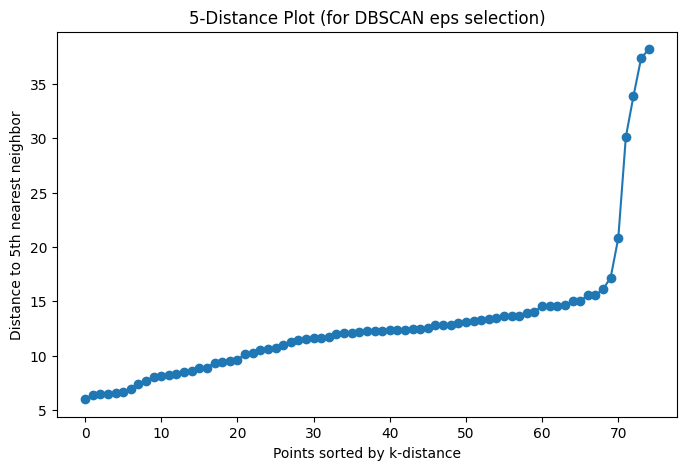

In [20]:
# Generating the k distance plot

# Fit NearestNeighbors model
n_neighbors = 6 #MinPts is 2 x dimension. Here, 2 x 3 = 6
nbrs = NearestNeighbors(n_neighbors= n_neighbors).fit(xyz) 

# Compute distances and indices of neighbors
neigh_dist, neigh_ind = nbrs.kneighbors(xyz)

# Sort distances for each neighbor column-wise
sorted_distances = np.sort(neigh_dist, axis=0)

# Select the distance to the k-th nearest neighbor for each point
k_distances = sorted_distances[:, n_neighbors - 2]

# Convert to list (for plotting)
k_dist_list = k_distances.tolist()

# Prepare x-axis indices
indices = list(range(len(k_dist_list)))

# Plot k-distance plot
plt.figure(figsize=(8, 5))
plt.plot(indices, k_dist_list, marker='o', linestyle='-')
plt.xlabel("Points sorted by k-distance")
plt.ylabel(f"Distance to {n_neighbors-1}th nearest neighbor")
plt.title(f"{n_neighbors-1}-Distance Plot (for DBSCAN eps selection)")
plt.show()

## Exercise 

We can use this plot to select our epsilon parameter. Below, you will see how to use this epsilon parameter to perform density-based scanning for epsilon = 10. On your own, try epsilon = 10-14 and decide which you think is the best for the data based on the output clusters

In [21]:
clusters = DBSCAN(eps= 10, min_samples=6).fit(xyz)
cluster_list = clusters.labels_.tolist()
xyz.insert(0, 'cluster', cluster_list)
xyz['cluster'].value_counts()

cluster
-1    44
 0    25
 1     6
Name: count, dtype: int64

<details>
  <summary>Click here to reveal the answer</summary>

  If you picked epsilon = 13, you are correct! This epsilon value is near the "knee" of our plot, and creates a variety of clusters in our protein, which is what we are looking for.

</details>

In [22]:
# Add the clustering info back into the original KEAP1 dataframe
keap1_clustered = keap1.merge(xyz, on=['x_coord', 'y_coord','z_coord'], how="inner") 
keap1_clustered.head()

,gene,res,x_coord,y_coord,z_coord,ModelID,cluster
0,KEAP1,603.0,12.405,-5.027,-20.555,ACH-002497,0
1,KEAP1,603.0,12.405,-5.027,-20.555,ACH-000844,0
2,KEAP1,568.0,14.684,-10.418,-10.226,ACH-000521,0
3,KEAP1,537.0,25.245,1.357,-2.301,ACH-002027,-1
4,KEAP1,511.0,17.776,-3.782,-12.189,ACH-002170,0


In [23]:
# Get the cluster radius of each cluster

# compute centroids
centroids = keap1_clustered.groupby("cluster")[["x_coord","y_coord","z_coord"]].mean()

# join centroids back
df = keap1_clustered.join(centroids, on="cluster", rsuffix="_centroid")

# compute distance from centroid
df["dist_to_centroid"] = np.sqrt(
    (df["x_coord"] - df["x_coord_centroid"])**2 +
    (df["y_coord"] - df["y_coord_centroid"])**2 +
    (df["z_coord"] - df["z_coord_centroid"])**2
)

# get cluster radius = max distance
radii = df.groupby("cluster")["dist_to_centroid"].max().rename("cluster_radius")

# merge back
keap1_clustered = df.merge(radii, on="cluster", how="left")
keap1_clustered.head()

,gene,res,x_coord,y_coord,z_coord,ModelID,cluster,x_coord_centroid,y_coord_centroid,z_coord_centroid,dist_to_centroid,cluster_radius
0,KEAP1,603.0,12.405,-5.027,-20.555,ACH-002497,0,15.460132,-1.368737,-19.533316,4.874480,19.579589
1,KEAP1,603.0,12.405,-5.027,-20.555,ACH-000844,0,15.460132,-1.368737,-19.533316,4.874480,19.579589
2,KEAP1,568.0,14.684,-10.418,-10.226,ACH-000521,0,15.460132,-1.368737,-19.533316,13.004525,19.579589
3,KEAP1,537.0,25.245,1.357,-2.301,ACH-002027,-1,-13.024353,-8.936098,13.662275,42.723733,73.177601
4,KEAP1,511.0,17.776,-3.782,-12.189,ACH-002170,0,15.460132,-1.368737,-19.533316,8.070072,19.579589


In [24]:
# Get the density of each cluster

# count points per cluster
counts = keap1_clustered['cluster'].value_counts().rename("n_points")

# get cluster radius 
radii = keap1_clustered.groupby("cluster")["cluster_radius"].first()

# compute volume of sphere
volume = (4/3) * np.pi * (radii ** 3)

# density = number of points / volume
density = (counts / volume).rename("density")

# merge densities back into the dataframe
cluster_props = pd.concat([counts, radii, volume.rename("volume"), density], axis=1)
keap1_clustered = keap1_clustered.merge(cluster_props["density"], on="cluster", how="left")
keap1_clustered.head()

,gene,res,x_coord,y_coord,z_coord,ModelID,cluster,x_coord_centroid,y_coord_centroid,z_coord_centroid,dist_to_centroid,cluster_radius,density
0,KEAP1,603.0,12.405,-5.027,-20.555,ACH-002497,0,15.460132,-1.368737,-19.533316,4.874480,19.579589,0.001209
1,KEAP1,603.0,12.405,-5.027,-20.555,ACH-000844,0,15.460132,-1.368737,-19.533316,4.874480,19.579589,0.001209
2,KEAP1,568.0,14.684,-10.418,-10.226,ACH-000521,0,15.460132,-1.368737,-19.533316,13.004525,19.579589,0.001209
3,KEAP1,537.0,25.245,1.357,-2.301,ACH-002027,-1,-13.024353,-8.936098,13.662275,42.723733,73.177601,0.000031
4,KEAP1,511.0,17.776,-3.782,-12.189,ACH-002170,0,15.460132,-1.368737,-19.533316,8.070072,19.579589,0.001209


## Adding Ground Truth Data 

Now we’ll add our “Ground Truth” data. In supervised machine learning, we need a training dataset that contains examples with known outcomes. The algorithm learns patterns from the relationships between the input features and these known outcomes, so it can make accurate predictions on new, unseen data, which is our test dataset. Essentially, the ground truth serves as a reference that guides the model in understanding what “correct” predictions look like.

Here, our ground truth data is in the form of Gene Set Enrichment Analysis (GSEA) scores. Each score tells us how much the NRF2 transcriptional subnetwork is active in cell lines that contain our mutations of interest. 

In [25]:
# Loading in the GSEA data for NRF2
gsea = pd.read_csv(f'{wd}/data/NRF2_GSEA_scores.csv')
gsea.head()

,SINGH_NFE2L2_TARGETS,DepMap_ID
0,8772.640340,ACH-000705
1,8317.610679,ACH-000062
2,8280.073630,ACH-000475
3,8261.140538,ACH-000686
4,7927.532781,ACH-000311


In [26]:
# Mapping based on common Model ID/DepMap ID column
keap1_ml = pd.merge(
    keap1_clustered,
    gsea,
    left_on="ModelID",
    right_on="DepMap_ID",
    how="inner"  # use 'left' or 'outer' if you want different merge behavior
)
keap1_ml = keap1_ml.drop(columns=["DepMap_ID"]) # drop unneeded column
keap1_ml.head()

,gene,res,x_coord,y_coord,z_coord,ModelID,cluster,x_coord_centroid,y_coord_centroid,z_coord_centroid,dist_to_centroid,cluster_radius,density,SINGH_NFE2L2_TARGETS
0,KEAP1,603.0,12.405,-5.027,-20.555,ACH-000844,0,15.460132,-1.368737,-19.533316,4.874480,19.579589,0.001209,4680.964017
1,KEAP1,568.0,14.684,-10.418,-10.226,ACH-000521,0,15.460132,-1.368737,-19.533316,13.004525,19.579589,0.001209,6688.988916
2,KEAP1,462.0,18.567,1.644,-19.746,ACH-000496,0,15.460132,-1.368737,-19.533316,4.332949,19.579589,0.001209,7813.355492
3,KEAP1,444.0,0.746,14.322,-10.793,ACH-000416,-1,-13.024353,-8.936098,13.662275,36.450270,73.177601,0.000031,5826.714628
4,KEAP1,413.0,10.755,7.133,-23.813,ACH-000852,0,15.460132,-1.368737,-19.533316,10.617603,19.579589,0.001209,5602.833561


In [27]:
# Normalize the GSEA scores to make data processing easier
keap1_ml['SINGH_NFE2L2_TARGETS_norm'] = (keap1_ml['SINGH_NFE2L2_TARGETS'] - keap1_ml['SINGH_NFE2L2_TARGETS'].mean()) / keap1_ml['SINGH_NFE2L2_TARGETS'].std()
keap1_ml.head()

,gene,res,x_coord,y_coord,z_coord,ModelID,cluster,x_coord_centroid,y_coord_centroid,z_coord_centroid,dist_to_centroid,cluster_radius,density,SINGH_NFE2L2_TARGETS,SINGH_NFE2L2_TARGETS_norm
0,KEAP1,603.0,12.405,-5.027,-20.555,ACH-000844,0,15.460132,-1.368737,-19.533316,4.874480,19.579589,0.001209,4680.964017,0.027326
1,KEAP1,568.0,14.684,-10.418,-10.226,ACH-000521,0,15.460132,-1.368737,-19.533316,13.004525,19.579589,0.001209,6688.988916,1.030865
2,KEAP1,462.0,18.567,1.644,-19.746,ACH-000496,0,15.460132,-1.368737,-19.533316,4.332949,19.579589,0.001209,7813.355492,1.592783
3,KEAP1,444.0,0.746,14.322,-10.793,ACH-000416,-1,-13.024353,-8.936098,13.662275,36.450270,73.177601,0.000031,5826.714628,0.599931
4,KEAP1,413.0,10.755,7.133,-23.813,ACH-000852,0,15.460132,-1.368737,-19.533316,10.617603,19.579589,0.001209,5602.833561,0.488043


For this algorithm, we will be doing a binary classification. Variants will be either "class1" (associated with changes in the NRF2 transcriptional subnetwork) or "class0" (not associated). For our training data, we will take any cell lines with GSEA scores that are greater than one standard deviation above the mean (approx top 15%), and assign variants in those cell lines as "class1".

In [28]:
# Compute the mean and std of the column
mean_val = keap1_ml['SINGH_NFE2L2_TARGETS_norm'].mean()
std_val = keap1_ml['SINGH_NFE2L2_TARGETS_norm'].std()

# Create the 'class' column: 1 if value > mean + 1*std, else 0
keap1_ml['class'] = (keap1_ml['SINGH_NFE2L2_TARGETS_norm'] > (mean_val + std_val)).astype(int)
keap1_ml.head()

,gene,res,x_coord,y_coord,z_coord,ModelID,cluster,x_coord_centroid,y_coord_centroid,z_coord_centroid,dist_to_centroid,cluster_radius,density,SINGH_NFE2L2_TARGETS,SINGH_NFE2L2_TARGETS_norm,class
0,KEAP1,603.0,12.405,-5.027,-20.555,ACH-000844,0,15.460132,-1.368737,-19.533316,4.874480,19.579589,0.001209,4680.964017,0.027326,0
1,KEAP1,568.0,14.684,-10.418,-10.226,ACH-000521,0,15.460132,-1.368737,-19.533316,13.004525,19.579589,0.001209,6688.988916,1.030865,1
2,KEAP1,462.0,18.567,1.644,-19.746,ACH-000496,0,15.460132,-1.368737,-19.533316,4.332949,19.579589,0.001209,7813.355492,1.592783,1
3,KEAP1,444.0,0.746,14.322,-10.793,ACH-000416,-1,-13.024353,-8.936098,13.662275,36.450270,73.177601,0.000031,5826.714628,0.599931,0
4,KEAP1,413.0,10.755,7.133,-23.813,ACH-000852,0,15.460132,-1.368737,-19.533316,10.617603,19.579589,0.001209,5602.833561,0.488043,0


## Supervised Machine Learning Algorithm

Now it is time to work on our main machine learning algorithm. 

First, we will look at our class sizes. We want to see how many class0 and class1 variants are in our data. If one group is substantially bigger than the other, this data is considered "unbalanced." 

In [29]:
keap1_ml['class'].value_counts()

class
0    52
1    14
Name: count, dtype: int64

Clearly, our data is unbalanced. There are two popular stratgies for balancing data: random oversampling and random undersampling. Random oversampling balances classes by duplicating existing samples from the minority class until it matches the majority size. Random undersampling balances classes by randomly removing samples from the majority class until it matches the minority size.

We don't want to get rid of any of our data, so here we will only practice balancing by random oversampling.

In [30]:
# Separate features and labels
X = keap1_ml.drop(columns=['class'])
y = keap1_ml['class']

# Apply random oversampling
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X, y)

# Combine back into a dataframe
keap1_ml_resampled = pd.concat([pd.DataFrame(X_resampled, columns=X.columns),
                                pd.DataFrame(y_resampled, columns=['class'])],
                               axis=1)

keap1_ml_resampled['class'].value_counts()

class
0    52
1    52
Name: count, dtype: int64

Now, we will get into the machine learning algorithm. Here, you will see how to use the algorithm on the unbalanced data. Then, you will try it on the resampled data on your own. 

We are going to try two different types of classical machine learning algorithms: Random Forest and XGBoost.

A Random Forest is an ensemble method that builds many decision trees on bootstrapped samples of the data and averages their predictions (or takes a majority vote) to reduce overfitting and improve generalization. Each tree is trained on a random subset of features, which increases diversity and stability.

In machine learning, features are the individual measurable properties or attributes of the data that the model uses to make predictions. Each feature represents one dimension of the input. The choice and quality of features strongly influence the model’s accuracy and interpretability. Our features here have to do with 3D properties of the variants. 

In [31]:
# Separate our features from our target prediction column
X = keap1_ml[['x_coord', 'y_coord', 'z_coord','cluster','cluster_radius','density']]
y = keap1_ml['class']

In [32]:
# Create our Random Forest model and fit it
rf_r = RandomForestClassifier(
    n_estimators=300,       # Number of decision trees in the forest
    random_state=42,        # Ensures reproducible results by fixing the random seed
    class_weight='balanced' # Automatically adjusts weights to handle imbalanced classes
)

rf_r.fit(X, y)

RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

Cross-validation is a technique to evaluate a machine learning model’s performance by splitting the data into multiple folds, training the model on some folds, and testing it on the remaining fold. This process is repeated for all folds, providing a more reliable estimate of the model’s generalization ability than a single train-test split.

In [33]:
# Apply the model
y_probs = cross_val_predict(rf_r, X, y, cv=5, method='predict_proba')[:, 1]
threshold = 0.55
y_pred_adjusted = (y_probs >= threshold).astype(int)

In [34]:
# Add the predictions to the dataframe
keap1_ml['rf_pred_adjusted'] = y_pred_adjusted
keap1_ml.head()

,gene,res,x_coord,y_coord,z_coord,ModelID,cluster,x_coord_centroid,y_coord_centroid,z_coord_centroid,dist_to_centroid,cluster_radius,density,SINGH_NFE2L2_TARGETS,SINGH_NFE2L2_TARGETS_norm,class,rf_pred_adjusted
0,KEAP1,603.0,12.405,-5.027,-20.555,ACH-000844,0,15.460132,-1.368737,-19.533316,4.874480,19.579589,0.001209,4680.964017,0.027326,0,1
1,KEAP1,568.0,14.684,-10.418,-10.226,ACH-000521,0,15.460132,-1.368737,-19.533316,13.004525,19.579589,0.001209,6688.988916,1.030865,1,0
2,KEAP1,462.0,18.567,1.644,-19.746,ACH-000496,0,15.460132,-1.368737,-19.533316,4.332949,19.579589,0.001209,7813.355492,1.592783,1,0
3,KEAP1,444.0,0.746,14.322,-10.793,ACH-000416,-1,-13.024353,-8.936098,13.662275,36.450270,73.177601,0.000031,5826.714628,0.599931,0,0
4,KEAP1,413.0,10.755,7.133,-23.813,ACH-000852,0,15.460132,-1.368737,-19.533316,10.617603,19.579589,0.001209,5602.833561,0.488043,0,1


Now, we will compute some different metrics to evaluate our model.

| Metric | Description | Formula | Notes |
|--------|-------------|---------|-------|
| **Accuracy** | Overall fraction of correctly predicted samples | (TP + TN) / (TP + TN + FP + FN) | Works well for balanced datasets, but can be misleading if classes are imbalanced |
| **Precision** | Fraction of predicted positives that are actually positive | TP / (TP + FP) | High precision → few false positives |
| **Recall** | Fraction of actual positives correctly identified | TP / (TP + FN) | High recall → few false negatives; important for rare events or disease detection |
| **F1 Score** | Harmonic mean of precision and recall | 2 * (Precision * Recall) / (Precision + Recall) | Balances precision and recall; useful for imbalanced datasets |
| **MCC (Matthews Correlation Coefficient)** | Quality of binary classification accounting for all outcomes | (TP*TN - FP*FN) / sqrt((TP+FP)(TP+FN)(TN+FP)(TN+FN)) | Ranges from -1 (wrong) to 1 (perfect); 0 = random; robust for imbalanced datasets |

In [35]:
# Look at the scores
print("Accuracy:", accuracy_score(y, y_pred_adjusted))
print("Precision:", precision_score(y, y_pred_adjusted))
print("Recall:", recall_score(y, y_pred_adjusted))
print("F1 Score:", f1_score(y, y_pred_adjusted))
print("MCC:", matthews_corrcoef(y, y_pred_adjusted))

Accuracy: 0.5454545454545454
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
MCC: -0.2935197542821371


Our scores don't look too good! Let's try looking at the ROC/AUC

The ROC AUC (Receiver Operating Characteristic – Area Under the Curve) measures a classifier’s ability to distinguish between classes across all possible decision thresholds. The ROC curve plots the true positive rate against the false positive rate, showing the trade-off between sensitivity and specificity. The AUC quantifies the overall performance: 1.0 means perfect classification, 0.5 means random guessing, and higher values indicate better discriminative ability.

ROC AUC: 0.982


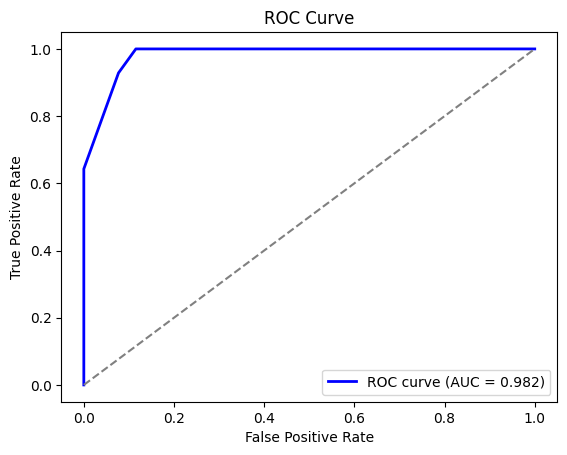

In [36]:
# Get predicted probabilities for class 1
y_probs = rf_r.predict_proba(X)[:, 1]  # probability of class 1

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y, y_probs)

# Compute ROC AUC score
roc_auc = roc_auc_score(y, y_probs)
print(f"ROC AUC: {roc_auc:.3f}")

# 4. Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # diagonal line for random chance
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

In [ ]:
# Now do this on your own for the resampled dataframe

You'll notice that the scores and ROC/AUC is much better for the resampled data. Now, let's try using the XGBoost model

XGBoost (Extreme Gradient Boosting) is a high-performance machine learning algorithm based on gradient boosting of decision trees. It builds trees sequentially, where each new tree tries to correct the errors of the previous trees by minimizing a loss function. XGBoost adds regularization, weighted trees, and efficient handling of missing data, making it faster and often more accurate than traditional gradient boosting. It’s widely used in competitions and real-world applications for classification, regression, and ranking tasks.

In [37]:
# Separate our features from our target prediction column
X = keap1_ml[['x_coord', 'y_coord', 'z_coord','cluster','cluster_radius','density']]
y = keap1_ml['class']

In [38]:
# Initialize XGBoost classifier
xgb_clf = xg.XGBClassifier(
    n_estimators=300,        # Number of trees
    max_depth=5,             # Maximum tree depth
    learning_rate=0.1,       # Step size shrinkage
    scale_pos_weight=(y==0).sum() / (y==1).sum(),  # Handle class imbalance
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'    # Avoid warning in recent XGBoost versions
)

# Fit the model on the full dataset (or cross-validation for evaluation)
xgb_clf.fit(X, y)

/opt/conda/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [21:06:45] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [39]:
# Apply the model
y_probs = cross_val_predict(xgb_clf, X, y, cv=5, method='predict_proba')[:, 1]
threshold = 0.55
y_pred_adjusted = (y_probs >= threshold).astype(int)

/opt/conda/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [21:06:49] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/conda/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [21:06:49] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/conda/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [21:06:49] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/conda/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [21:06:49] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/conda/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [21:06:49] WARNING: /w

In [40]:
# Add predictions to dataframe
keap1_ml['xgb_pred_adjusted'] = y_pred_adjusted
keap1_ml.head()

,gene,res,x_coord,y_coord,z_coord,ModelID,cluster,x_coord_centroid,y_coord_centroid,z_coord_centroid,dist_to_centroid,cluster_radius,density,SINGH_NFE2L2_TARGETS,SINGH_NFE2L2_TARGETS_norm,class,rf_pred_adjusted,xgb_pred_adjusted
0,KEAP1,603.0,12.405,-5.027,-20.555,ACH-000844,0,15.460132,-1.368737,-19.533316,4.874480,19.579589,0.001209,4680.964017,0.027326,0,1,1
1,KEAP1,568.0,14.684,-10.418,-10.226,ACH-000521,0,15.460132,-1.368737,-19.533316,13.004525,19.579589,0.001209,6688.988916,1.030865,1,0,0
2,KEAP1,462.0,18.567,1.644,-19.746,ACH-000496,0,15.460132,-1.368737,-19.533316,4.332949,19.579589,0.001209,7813.355492,1.592783,1,0,0
3,KEAP1,444.0,0.746,14.322,-10.793,ACH-000416,-1,-13.024353,-8.936098,13.662275,36.450270,73.177601,0.000031,5826.714628,0.599931,0,0,0
4,KEAP1,413.0,10.755,7.133,-23.813,ACH-000852,0,15.460132,-1.368737,-19.533316,10.617603,19.579589,0.001209,5602.833561,0.488043,0,1,1


In [41]:
# Compute metrics
print("Accuracy:", accuracy_score(y, y_pred_adjusted))
print("Precision:", precision_score(y, y_pred_adjusted))
print("Recall:", recall_score(y, y_pred_adjusted))
print("F1 Score:", f1_score(y, y_pred_adjusted))
print("MCC:", matthews_corrcoef(y, y_pred_adjusted))

Accuracy: 0.4696969696969697
Precision: 0.043478260869565216
Recall: 0.07142857142857142
F1 Score: 0.05405405405405406
MCC: -0.3017005694251908


ROC AUC: 0.982


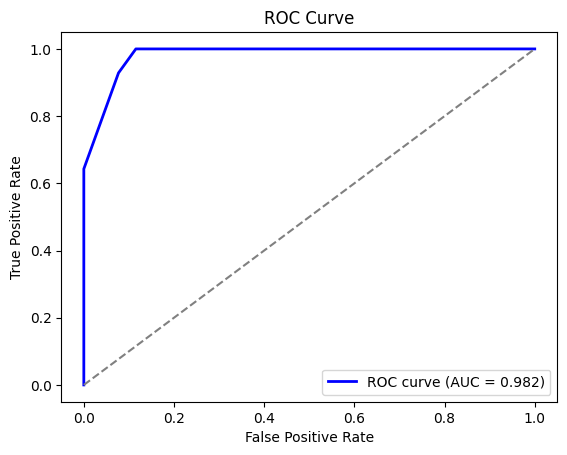

In [42]:
# Plot ROC/AUC

# Get predicted probabilities for class 1 from XGBoost
y_probs = xgb_clf.predict_proba(X)[:, 1]  # probability of class 1

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y, y_probs)

# Compute ROC AUC score
roc_auc = roc_auc_score(y, y_probs)
print(f"ROC AUC: {roc_auc:.3f}")

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # diagonal line for random chance
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

In [ ]:
# Now try it on your own for the resampled data

## Visualizing the Results

We can see that our metrics look the best for the resampled data with the XGBoost model. Let's visualize the clusters picked out by this model.

In [43]:
keap1_ml_resampled.head()

,gene,res,x_coord,y_coord,z_coord,ModelID,cluster,x_coord_centroid,y_coord_centroid,z_coord_centroid,dist_to_centroid,cluster_radius,density,SINGH_NFE2L2_TARGETS,SINGH_NFE2L2_TARGETS_norm,class
0,KEAP1,603.0,12.405,-5.027,-20.555,ACH-000844,0,15.460132,-1.368737,-19.533316,4.874480,19.579589,0.001209,4680.964017,0.027326,0
1,KEAP1,568.0,14.684,-10.418,-10.226,ACH-000521,0,15.460132,-1.368737,-19.533316,13.004525,19.579589,0.001209,6688.988916,1.030865,1
2,KEAP1,462.0,18.567,1.644,-19.746,ACH-000496,0,15.460132,-1.368737,-19.533316,4.332949,19.579589,0.001209,7813.355492,1.592783,1
3,KEAP1,444.0,0.746,14.322,-10.793,ACH-000416,-1,-13.024353,-8.936098,13.662275,36.450270,73.177601,0.000031,5826.714628,0.599931,0
4,KEAP1,413.0,10.755,7.133,-23.813,ACH-000852,0,15.460132,-1.368737,-19.533316,10.617603,19.579589,0.001209,5602.833561,0.488043,0


In [44]:
# Sum class 1 counts per cluster
class1_counts = keap1_ml.groupby('cluster')['xgb_pred_adjusted'].sum()

# Find the cluster with the maximum number of class 1
max_cluster = class1_counts.idxmax()
max_count = class1_counts.max()

print(f"Cluster with most class 1: {max_cluster} (count = {max_count})")

Cluster with most class 1: 0 (count = 20)


In [45]:
# Filter for cluster 0 and class 1
cluster0_class1_variants = keap1_ml[(keap1_ml['cluster'] == 0) & 
                                              (keap1_ml['xgb_pred_adjusted'] == 1)]

# Display the result
cluster0_class1_variants.head()

,gene,res,x_coord,y_coord,z_coord,ModelID,cluster,x_coord_centroid,y_coord_centroid,z_coord_centroid,dist_to_centroid,cluster_radius,density,SINGH_NFE2L2_TARGETS,SINGH_NFE2L2_TARGETS_norm,class,rf_pred_adjusted,xgb_pred_adjusted
0,KEAP1,603.0,12.405,-5.027,-20.555,ACH-000844,0,15.460132,-1.368737,-19.533316,4.874480,19.579589,0.001209,4680.964017,0.027326,0,1,1
4,KEAP1,413.0,10.755,7.133,-23.813,ACH-000852,0,15.460132,-1.368737,-19.533316,10.617603,19.579589,0.001209,5602.833561,0.488043,0,1,1
6,KEAP1,361.0,2.263,-4.391,-26.592,ACH-000727,0,15.460132,-1.368737,-19.533316,15.268378,19.579589,0.001209,4676.283914,0.024987,0,1,1
8,KEAP1,336.0,11.276,-11.398,-30.314,ACH-000481,0,15.460132,-1.368737,-19.533316,15.307391,19.579589,0.001209,4230.019637,-0.198039,0,0,1
25,KEAP1,567.0,13.149,-10.451,-6.713,ACH-000887,0,15.460132,-1.368737,-19.533316,15.880470,19.579589,0.001209,5362.052502,0.367710,0,1,1


In [46]:
# Load PDB file (AlphaFold or PDB)
with open(f"{wd}/data/AF-Q14145-F1-model_v3.pdb", "r") as f:
    pdb_data = f.read()

# Initialize 3D viewer
view = py3Dmol.view(width=800, height=600)
view.addModel(pdb_data, 'pdb')
view.setStyle({'cartoon': {'color':'lightblue'}})  # main protein in light blue

# List of residues to highlight in red
red_residues = cluster0_class1_variants['res'].tolist()  # cluster 0 class 1 residue positions

# Highlight each residue in red
for res in red_residues:
    view.addStyle({'resi': res}, {'stick': {'color': 'red'}})

# Focus on the protein and show
view.zoomTo()
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

We can see that all the residues highlighted are in the KEAP1/NRF2 interaction site. It makes a lot of sense that mutations here would cause changes in the NRF2 transcriptional subnetwork! This shows how we can use Machine Learning to find biologically relevant patterns.

**Optional: On your own, try adjusting things like the threshold, or the features used to see how that affects the scores.**

This workflow was developed by Kriti Shukla at the University of North Carolina at Chapel Hill. If you are interested in learning more about how similar work can be applied in scientific contexts, please see the following paper: 

Shukla, K; Idanwekhai, K; Naradikian, M; Ting, S; Schoenberger, S; Brunk, E. Machine Learning of Three-Dimensional Protein Structures to Predict the Functional Impacts of Genome Variation. J. Chem. Inf. Model. 2024, 64, 13, 5328–5343